# Évaluation d'un modèle de classification

## Pourquoi ce notebook est important

On a déjà vu dans `03-use-sklearn-algorithms/03-evaluate-regression-model` comment évaluer un modèle de **régression** (MAE, RMSE, R²...). Ici on s'attaque au cas **classification**, qui pose des questions très différentes :

> **L'analogie à garder en tête :** un modèle de classification est comme un **détecteur de fumée**. Il doit sonner quand il y a un vrai incendie (**vrai positif**) et rester silencieux sinon (**vrai négatif**). Mais il peut se tromper de deux façons :
>
> - **Fausse alerte** (*faux positif*) : il sonne alors qu'il n'y a rien — agaçant mais pas catastrophique.
> - **Incendie raté** (*faux négatif*) : il ne sonne pas alors que ça brûle — potentiellement mortel.
>
> **Ces deux erreurs ne sont pas équivalentes.** Selon le contexte, on voudra privilégier l'une ou l'autre. C'est tout l'enjeu de l'évaluation d'un modèle de classification : **choisir la bonne métrique en fonction du coût métier des erreurs**.

## Le plan

1. **Comprendre le dataset MNIST** — 70 000 images de chiffres manuscrits (28×28 pixels).
2. **Simplifier en problème binaire** : *« cette image est-elle un 5, oui ou non ? »*. Plus simple à expliquer pour voir les concepts clés.
3. **L'accuracy et son piège** : pourquoi un score élevé ne veut parfois rien dire.
4. **Matrice de confusion** : le vrai outil de diagnostic d'un classifieur.
5. **Précision, rappel, F1** : trois métriques dérivées de la matrice, chacune répondant à une question métier différente.
6. **Arbitrage précision/rappel** : déplacer le seuil de décision pour ajuster le compromis.
7. **Courbe ROC et AUC** : visualiser et résumer la capacité discriminative globale du modèle.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", parser="auto", version=1)
data = mnist.data
target = mnist.target

In [3]:
# data.join(target).to_csv("../../data/mnist.csv", index=False)

In [4]:
# mnist_csv = pd.read_csv("../../data/mnist.csv")
# data = mnist_csv.drop("class", axis=1)
# target = mnist_csv["class"]

## Comprendre les données

Le dataset **MNIST** est un classique absolu en deep learning et en machine learning : 70 000 images de chiffres manuscrits (0 à 9), chacune de **28×28 pixels** en niveaux de gris.

**Pourquoi MNIST est souvent le premier exemple ?**
- **Petite taille** (~11 Mo), rapide à charger et à entraîner.
- **Données propres** (pré-nettoyées, labellisées).
- **Problème visuellement intuitif** : on *voit* ce que le modèle doit apprendre.
- **Baseline bien connue** : on sait ce qu'un « bon » modèle devrait atteindre (> 99% d'accuracy avec un bon algo).

> **Format des données :** chaque image est aplatie en un vecteur de **784 valeurs** (= 28 × 28), chaque valeur étant l'intensité d'un pixel entre 0 (blanc) et 255 (noir).

In [5]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [6]:
data.shape, target.shape

((70000, 784), (70000,))

**On affiche le premier digit** pour vérifier qu'on a bien compris le format. Un vecteur de 784 valeurs doit pouvoir être remis en forme `(28, 28)` et affiché comme une image.

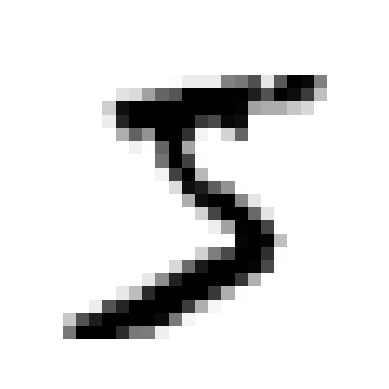

In [7]:
X = data.values
first_digit = X[0]
first_digit_image = first_digit.reshape(28, 28)

plt.imshow(first_digit_image, cmap="binary")
plt.axis("off");

**...et le label correspondant** — qu'est-ce que ce chiffre est censé représenter ?

In [8]:
target[0]

'5'

**On convertit les labels** de chaînes de caractères (`'5'`) vers des entiers (`5`). Pourquoi ? Parce que la plupart des algorithmes de classification scikit-learn attendent des labels numériques, et c'est plus pratique pour faire des comparaisons et des filtres (`y == 5`).

In [9]:
y = target.astype(np.uint8)
assert y[0] == 5

**On affiche les 25 premières images** pour avoir une vue d'ensemble du dataset. C'est un geste d'EDA : *« à quoi ressemblent mes données ? »*.

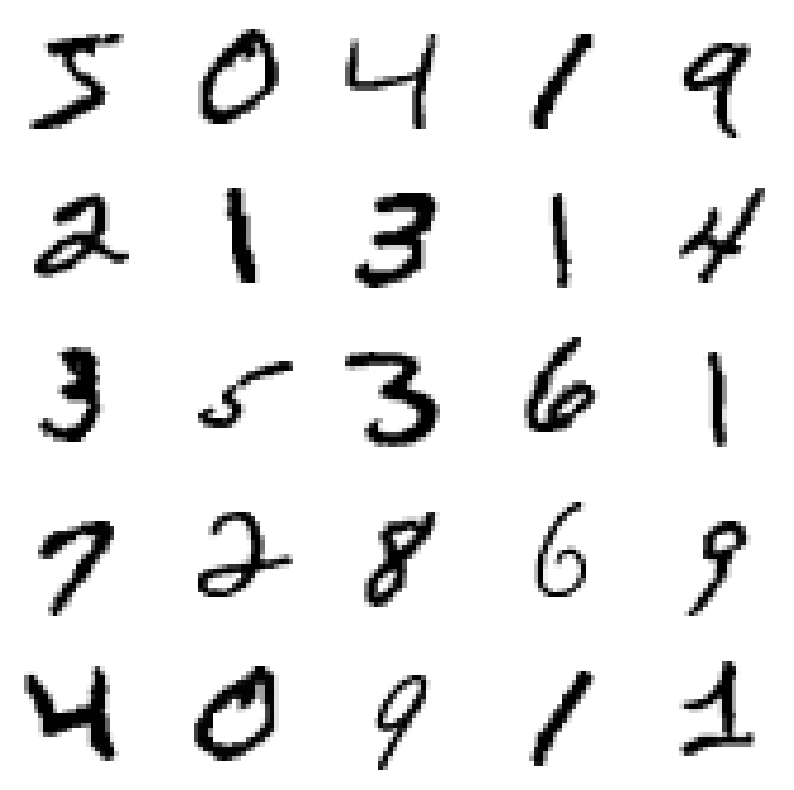

In [10]:
plt.figure(figsize=(10,10))
for i in range(25):
    digit_image = X[i].reshape(28, 28)
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(digit_image, cmap=plt.cm.binary)
    plt.axis("off")
#    plt.xlabel(y[i])

**Note importante :** les digits sont déjà **distribués aléatoirement** dans le jeu de données (c'est une propriété de MNIST). Pas besoin de passer par `train_test_split` pour mélanger — on peut juste faire un **découpage par index**. Les **60 000 premiers** servent au train, les **10 000 derniers** au test.

> **⚠️ Attention :** ce raccourci n'est valable que parce qu'on sait que les données sont déjà mélangées. Sur un dataset « brut » (par exemple trié par date ou par classe), couper sans `shuffle` introduirait un biais massif. **Quand on a un doute, on utilise toujours `train_test_split` avec `shuffle=True`.**

In [11]:
# Les premières 60000 images -> train set
# Les dernières 10000 images -> test set

X_train, X_test, y_train, y_test = X[:60_000], X[60_000:], y[:60_000], y[60_000:]

## Classification binaire

**On simplifie le problème** : au lieu de distinguer les 10 chiffres, on se pose une question plus simple — *« cette image est-elle un 5, oui ou non ? »*. C'est donc un problème de **classification binaire** (2 classes : `5` / `pas 5`).

> **Pourquoi simplifier ?** Parce que l'accuracy, la précision, le rappel, la matrice de confusion... sont d'abord conçus pour **2 classes**. En binaire, on a une notion claire de **positif** (ici, la classe `5`) et **négatif** (tout le reste). Ça permet d'introduire tous les concepts sans ajouter la complexité du multiclasse.

In [12]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)
print(f"Il existe {y_train_5.sum()} 5 dans le jeu de train.")

Il existe 5421 5 dans le jeu de train.


In [13]:
print(f"{y_train_5.sum()/y_train.shape[0]*100:.2f}% des digits sont des 5.")

9.04% des digits sont des 5.


**On utilise un SGDClassifier** — *Stochastic Gradient Descent Classifier*. C'est un classifieur linéaire (une régression logistique, en gros) entraîné par descente de gradient stochastique. Rapide, simple, parfait pour une démo.

> **Pourquoi ce choix ?** Parce que l'objectif ici n'est **pas** de trouver le meilleur modèle pour classer les 5, mais d'illustrer **les métriques d'évaluation**. Un modèle simple suffit — et ses erreurs seront suffisamment nombreuses pour être intéressantes à analyser.

In [14]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=2, n_jobs=-1)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(n_jobs=-1, random_state=2)

In [15]:
sgd_clf.predict([first_digit])

array([ True])

**C'est bien un 5 !** Le modèle a donné la bonne réponse sur l'exemple qu'on lui a montré. Mais... **une seule prédiction correcte ne veut rien dire**. Il faut évaluer sur **beaucoup d'exemples**, en cross-validation, avec une métrique pertinente.

## Mesures de performance avec la cross-validation

On va commencer par la métrique la plus intuitive : l'**accuracy** (*justesse*).

$
\Large{
\text{accuracy} = \frac{\text{nombre de bonnes prédictions}}{\text{nombre total de prédictions}}
}
$

**Interprétation simple :** *« sur 100 prédictions, combien sont correctes ? »*. Un score de 0,95 signifie 95% de bonnes réponses.

On utilise la **cross-validation** pour avoir une estimation fiable (pas dépendante d'un tirage particulier train/val), comme vu dans le notebook sur la cross-validation.

In [16]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy", n_jobs=-1)

array([0.9636 , 0.96275, 0.9657 ])

**~96% d'accuracy** — excellent, non ? **Mauvais réflexe de s'enthousiasmer tout de suite.** Avant de célébrer, il faut **toujours** comparer à un **prédicteur bête** pour voir si le modèle « fait vraiment quelque chose ».

**Le test du prédicteur bête :** on crée un classifieur qui prédit **toujours la classe majoritaire** — ici, *« ce n'est jamais un 5 »*. C'est le genre de prédicteur qui ne sait absolument rien du problème.

In [17]:
from sklearn.dummy import DummyClassifier
never_5_clf = DummyClassifier(strategy="constant", constant=0)
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

**~91% d'accuracy... pour un algorithme qui dit toujours « non ».**

> **🎯 Le piège de l'accuracy sur des classes déséquilibrées :**
>
> Seulement **~10%** des chiffres sont des 5. Donc si on dit toujours « pas un 5 », on a raison... **90% du temps** — sans rien apprendre. Notre vrai modèle fait 96%, soit seulement **5 points de mieux** qu'un prédicteur stupide. Pas si impressionnant, finalement.
>
> **Conséquence pratique :** sur les datasets **déséquilibrés** (détection de fraude, maladies rares, anomalies industrielles, clics publicitaires...), **l'accuracy est une métrique trompeuse**. Il faut utiliser d'autres métriques (précision, rappel, F1, ROC-AUC) pour évaluer sérieusement la qualité du modèle.
>
> **Règle d'or :** *toujours comparer à un `DummyClassifier`* avant de célébrer un score. Si ton modèle ne bat pas clairement le dummy, soit le problème est très dur, soit ton modèle n'a rien appris.

## Matrice de confusion — le vrai outil de diagnostic

L'accuracy est trop brute : elle mélange **tous les types d'erreurs** en un seul chiffre. Pour comprendre *comment* un classifieur se trompe, on utilise la **matrice de confusion**.

### Anatomie d'une matrice de confusion (binaire)

|  | **Prédit : Négatif** | **Prédit : Positif** |
|---|:---:|:---:|
| **Réel : Négatif** | ✅ TN — *Vrai Négatif* | ❌ FP — *Faux Positif* |
| **Réel : Positif** | ❌ FN — *Faux Négatif* | ✅ TP — *Vrai Positif* |

**Les 4 cases à connaître par cœur :**

- **TP (*True Positive*)** — l'exemple est vraiment positif, le modèle le dit. ✅
- **TN (*True Negative*)** — l'exemple est vraiment négatif, le modèle le dit. ✅
- **FP (*False Positive*)** — le modèle dit « positif » alors que non. ❌ **Fausse alerte.**
- **FN (*False Negative*)** — le modèle dit « négatif » alors que oui. ❌ **Occasion manquée.**

**Pourquoi c'est essentiel :** la matrice révèle **quel type** d'erreur le modèle commet. Deux modèles peuvent avoir la même accuracy mais des profils d'erreurs **opposés** — et dans un contexte métier, ça change tout.

> **Exemples pour bien comprendre :**
>
> - **Test médical** pour une maladie grave → un FN (dire *« vous êtes en bonne santé »* à quelqu'un qui est malade) est **beaucoup plus grave** qu'un FP (faire faire un examen complémentaire inutile à quelqu'un en bonne santé). On veut **minimiser les FN**.
> - **Spam filter** → un FN (laisser passer un spam) est **agaçant**. Un FP (classer un vrai email important comme spam) est **beaucoup plus grave**. On veut **minimiser les FP**.
> - **Détection de fraude bancaire** → un FN (laisser passer une fraude) coûte cher. Un FP (bloquer une transaction légitime) agace le client. L'équilibre dépend du montant.
>
> **Sans la matrice de confusion, on ne peut pas faire ces arbitrages.**

![matrice](https://leandeep.com/images/matrice-de-classification.png)

### Prédiction sur les données de test

Avant de dessiner la matrice, il faut des **prédictions**. On entraîne donc le modèle une dernière fois sur **tout le train**, puis on prédit sur le test.

In [18]:
sgd_clf = SGDClassifier(random_state=2, n_jobs=-1)
sgd_clf.fit(X_train, y_train_5)

y_test_pred = sgd_clf.predict(X_test)

On va maintenant utiliser une [matrice de confusion](https://fr.wikipedia.org/wiki/Matrice_de_confusion) pour examiner comment le modèle se trompe — pas juste combien de fois.

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_5, y_test_pred)
cm

array([[9047,   61],
       [ 227,  665]])

**Le résultat brut est un tableau 2×2 de chiffres** — lisible mais **pas très parlant**. On va la rendre plus **visuelle** avec `yellowbrick`, qui affiche une heatmap colorée et annotée.

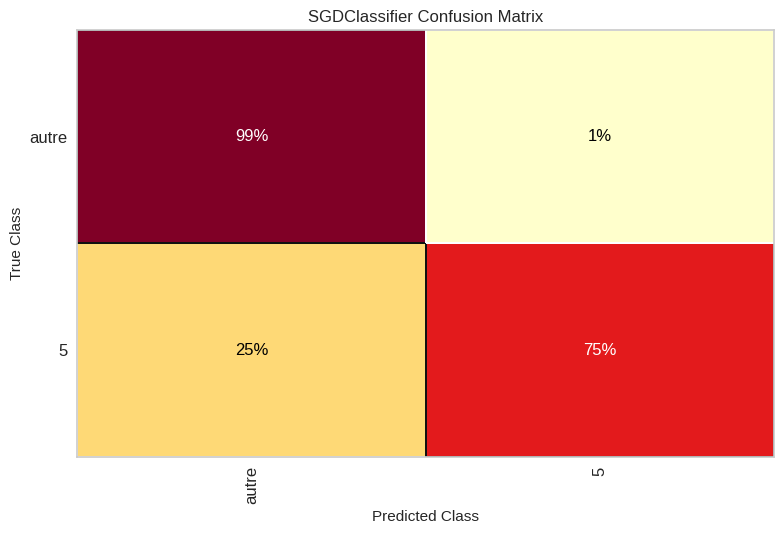

ConfusionMatrix(ax=<Axes: title={'center': 'SGDClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>,
                classes=['autre', '5'],
                cmap=<matplotlib.colors.ListedColormap object at 0x7f09f4b8e410>,
                estimator=SGDClassifier(n_jobs=-1, random_state=2),
                percent=True)

In [20]:
from yellowbrick.classifier import confusion_matrix

confusion_matrix(
    SGDClassifier(random_state=2, n_jobs=-1),
    X_train, y_train_5, X_test, y_test_5,
    classes=['autre', '5'], percent=True
)

**Lecture guidée :**

- **La diagonale** (TN, TP) contient les prédictions correctes. Plus elle est « chaude », mieux le modèle s'en sort.
- **Hors diagonale** : les erreurs. FP en haut à droite, FN en bas à gauche.
- Sur ce modèle, on voit que la **ligne des positifs** (les 5) est celle qui contient le plus d'erreurs : le modèle **rate beaucoup de 5** (FN élevé) mais se trompe peu en disant « 5 » (FP faible).

> **Interprétation métier :** ce modèle est **prudent** — il préfère ne pas dire « 5 » si ce n'est pas clair. C'est bien si on veut peu de fausses alertes, mal si on veut détecter tous les 5.

**On peut rééquilibrer le modèle** si les faux négatifs sont trop coûteux. Une façon simple : utiliser `class_weight='balanced'` sur le `SGDClassifier`. Scikit-learn donne alors **plus de poids** aux exemples de la classe minoritaire pendant l'entraînement → le modèle ose davantage dire « 5 », au prix de plus de fausses alertes.

> **Mental model :** `class_weight='balanced'` dit au modèle *« chaque 5 compte comme si c'était 9 exemples (parce qu'il y a 9× moins de 5 que de non-5) »*. Le modèle va donc plus « écouter » les 5 pendant l'apprentissage.
>
> **C'est un ajustement gratuit à essayer** dès qu'on a un dataset déséquilibré et qu'on veut plus de sensibilité (recall). On verra le résultat dans la prochaine matrice de confusion.

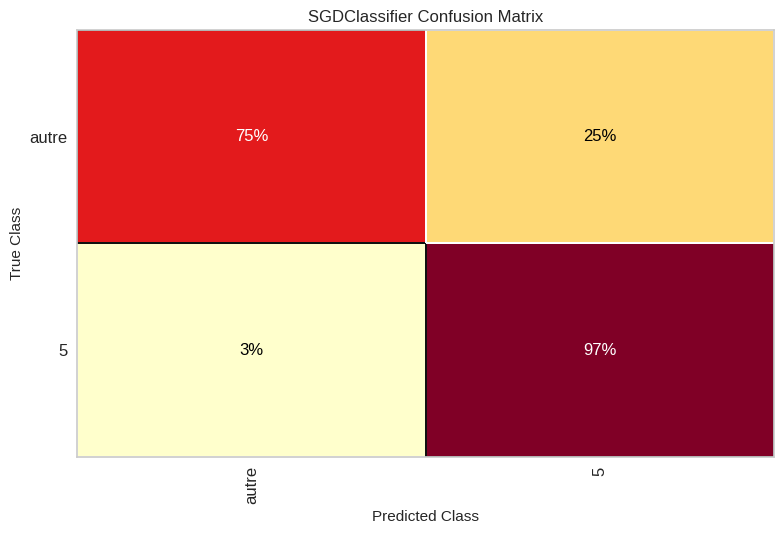

ConfusionMatrix(ax=<Axes: title={'center': 'SGDClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>,
                classes=['autre', '5'],
                cmap=<matplotlib.colors.ListedColormap object at 0x7f09f4bdf290>,
                estimator=SGDClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=2),
                percent=True)

In [21]:
from yellowbrick.classifier import confusion_matrix

confusion_matrix(
    SGDClassifier(class_weight="balanced", random_state=2, n_jobs=-1),
    X_train, y_train_5, X_test, y_test_5,
    classes=['autre', '5'], percent=True
)

## Métriques issues de la matrice de confusion

La matrice de confusion contient tout ce qu'il faut, mais c'est parfois trop. On veut souvent un **seul chiffre** qui résume la qualité du modèle sous un angle précis. D'où les métriques dérivées, chacune répondant à une question spécifique.

### Précision — *« quand mon modèle dit positif, a-t-il raison ? »*

$
\Large{
\text{Précision} = \frac{TP}{TP + FP}
}
$

**En langage courant :** parmi toutes les prédictions « positif » du modèle, quelle proportion est effectivement correcte ?

- Un modèle avec une **précision de 1** ne fait **jamais de faux positif** : quand il dit « positif », c'est toujours vrai (mais il peut rater beaucoup de vrais positifs — la précision ne dit rien là-dessus).
- **Précision faible** → beaucoup de fausses alertes.

### Rappel — *« parmi tous les vrais positifs, combien mon modèle en détecte-t-il ? »*

(aussi appelé **sensibilité** ou ***recall***)

$
\Large{
\text{Rappel} = \frac{TP}{TP + FN}
}
$

**En langage courant :** parmi tous les cas réellement positifs, quelle proportion le modèle a-t-il réussi à identifier comme telle ?

- Un modèle avec un **rappel de 1** **ne rate aucun positif** : dès qu'il y a un cas positif, le modèle le trouve (mais il peut faire beaucoup de fausses alertes).
- **Rappel faible** → beaucoup d'occasions manquées.

### L'image à retenir

![Précision vs Rappel](https://upload.wikimedia.org/wikipedia/commons/2/26/Precisionrecall.svg)

### F1 score — *« l'équilibre entre précision et rappel »*

$
\Large{
F_1 = \frac{2}{\frac{1}{\text{précision}} + \frac{1}{\text{rappel}}} = 2 \cdot \frac{\text{précision} \cdot \text{rappel}}{\text{précision} + \text{rappel}}
}
$

**C'est la moyenne harmonique de la précision et du rappel.** Pourquoi harmonique et pas arithmétique ?

> **L'intuition :** la moyenne harmonique **pénalise les déséquilibres**. Si un modèle a précision = 1 et rappel = 0, la moyenne arithmétique donne 0,5 (c'est-à-dire *« moyen »*). Mais c'est un modèle **inutile** — il ne trouve jamais rien. La moyenne harmonique dit : **F1 = 0**, ce qui est bien plus honnête.
>
> **Conclusion :** F1 est proche de sa plus petite valeur d'entrée. Pour avoir un F1 élevé, **il faut que précision et rappel soient tous les deux bons**. C'est exactement ce qu'on veut si on n'a pas de préférence marquée pour l'un ou l'autre.

### En résumé — quand utiliser quelle métrique ?

| Métrique | Cas d'usage | Exemple typique |
|---|---|---|
| **Accuracy** | Classes **équilibrées** (~50/50) et coûts d'erreur similaires | Classification de genre |
| **Précision** | Optimiser les **vrais positifs** parmi les alertes ; un FP est coûteux | **Filtre anti-spam** : rater un vrai email (FP) est pire que laisser passer un spam |
| **Rappel** | Ne **pas rater** les positifs ; un FN est coûteux | **Diagnostic médical** : rater une maladie (FN) est pire qu'un test inutile |
| **F1 Score** | Classes **déséquilibrées** **et** on veut un **équilibre** précision/rappel | Détection d'anomalies industrielles, classification multi-label |
| **ROC-AUC** | Évaluer la **capacité discriminative globale** indépendamment du seuil | Comparaison de modèles dans un concours |

![quelques métriques](../../images/understand_confusion_matrix.jpg)

> **🎯 Règle d'or : le choix de la métrique dépend des objectifs métier.**
>
> Avant de choisir une métrique, **demande-toi** :
>
> - Quel est le **coût d'un faux positif** dans ce contexte ?
> - Quel est le **coût d'un faux négatif** ?
> - Les classes sont-elles équilibrées ou pas ?
>
> **Il n'y a pas de métrique « universellement meilleure »** — chacune répond à une question différente. Se tromper de métrique, c'est **optimiser pour le mauvais objectif** pendant des mois. L'alignement entre la métrique et le besoin métier est ce qui distingue un modèle utile d'un modèle qui marche sur le papier mais échoue en production.

### Utilisation dans scikit-learn

Les fonctions `precision_score`, `recall_score`, `f1_score` de `sklearn.metrics` calculent ces trois métriques directement à partir des prédictions.

In [22]:
sgd_clf = SGDClassifier(random_state=2, n_jobs=-1)
sgd_clf.fit(X_train, y_train_5)

y_test_pred = sgd_clf.predict(X_test)

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(f"Precision = {precision_score(y_test_5, y_test_pred):.2f}")

Precision = 0.92


**Lecture :** *« lorsque notre modèle prétend avoir reconnu un 5, il n'a raison que 86% du temps. »*

Autrement dit, **14% de fausses alertes** parmi les « c'est un 5 » — c'est notre taux de **faux positifs** relatif aux prédictions positives.

In [24]:
print(f"Recall = {recall_score(y_test_5, y_test_pred):.2f}")

Recall = 0.75


**Lecture :** *« lorsque notre modèle se trouve devant un vrai 5, il ne le reconnaît que dans 72% des cas. »*

Autrement dit, **28% des 5 sont ratés** par le modèle — c'est notre **taux de faux négatifs** relatif à la classe positive.

In [25]:
print(f"f1 = {f1_score(y_test_5, y_test_pred):.2f}")

f1 = 0.82


**Lecture :** le F1 est un **score de compromis** entre précision et rappel. Un chiffre entre 0 et 1, où 1 = parfait.

**Pour ce modèle** : F1 ≈ 0,78. Ce n'est pas mauvais, mais clairement pas excellent — on voit que le rappel tire l'ensemble vers le bas. Un modèle avec une meilleure détection des 5 aurait un F1 plus élevé.

## Arbitrage entre précision et rappel

### L'idée du seuil de décision

Un classifieur binaire comme `SGDClassifier` ne prédit pas directement « 5 » ou « pas 5 ». En interne, il calcule d'abord un **score continu** (par exemple une probabilité ou une distance à un hyperplan), puis **compare ce score à un seuil** :

- **Score > seuil** → prédit « positif ».
- **Score ≤ seuil** → prédit « négatif ».

**Par défaut, le seuil est à 0** (ou à 0,5 pour une probabilité). Mais **on peut le changer** pour ajuster le compromis :

- **Seuil élevé** → le modèle est **strict** : il ne prédit « positif » que s'il est très sûr. Résultat : **précision élevée**, **rappel faible**.
- **Seuil faible** → le modèle est **laxiste** : il dit « positif » à la moindre suspicion. Résultat : **rappel élevé**, **précision faible**.

> **Lorsqu'on favorise la précision, on sacrifie le rappel, et réciproquement.** Il n'y a **pas de mystère** là-dedans — c'est purement géométrique.

![Sensibilité et spécificité](../../images/precision-recall-thresholds.png)

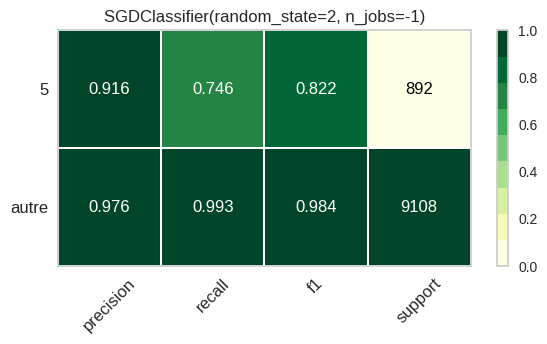

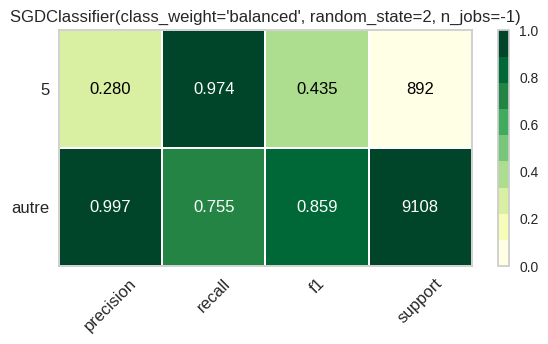

In [26]:
from yellowbrick.classifier import ClassificationReport

def visualize_model(X_train, y_train, X_test, y_test, estimator, title, **kwargs):

    visualizer = ClassificationReport(
        estimator,
        classes=['autre', '5'], support=True, title=title,
        cmap="YlGn", size=(600, 360), **kwargs
    )
    visualizer.fit(X_train, y_train)
    visualizer.score(X_test, y_test)
    visualizer.show()

visualize_model(
    X_train, y_train_5, X_test, y_test_5,
    SGDClassifier(random_state=2, n_jobs=-1),
    title = "SGDClassifier(random_state=2, n_jobs=-1)"
)
visualize_model(
    X_train, y_train_5, X_test, y_test_5,
    SGDClassifier(class_weight='balanced', random_state=2, n_jobs=-1),
    title = "SGDClassifier(class_weight='balanced', random_state=2, n_jobs=-1)"
)

### Courbe Précision / Rappel

Pour visualiser ce compromis, on trace la **courbe précision / rappel** : l'évolution conjointe de la précision et du rappel **en fonction du seuil de décision**.

> **Lecture de la courbe :**
> - **Plus la courbe est proche du coin supérieur droit** (précision = 1, rappel = 1), meilleur est le modèle.
> - **La position optimale dépend de ton problème** : en médecine, tu vas descendre très à droite (rappel maximal, quitte à perdre en précision) ; en spam filter, tu vas rester en haut à gauche.
>
> Cette courbe est **l'outil de choix** pour **décider du seuil de décision** en production.

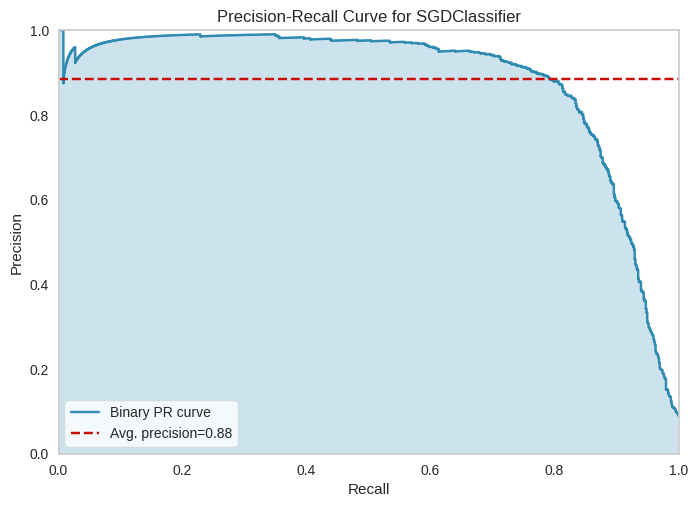

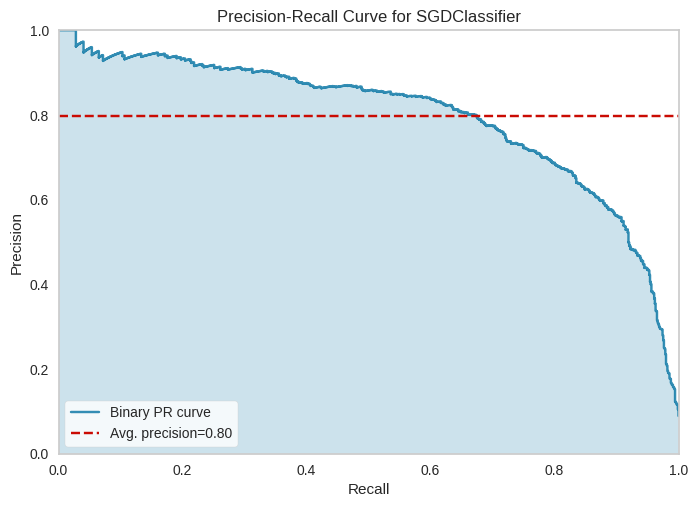

In [27]:
from yellowbrick.classifier import precision_recall_curve

precision_recall_curve(
    SGDClassifier(random_state=2, n_jobs=-1),
    X_train, y_train_5, X_test, y_test_5
)
precision_recall_curve(
    SGDClassifier(class_weight='balanced', random_state=2, n_jobs=-1),
    X_train, y_train_5, X_test, y_test_5
);

### La courbe ROC et l'AUC

**La courbe ROC** (*Receiver Operating Characteristic*) est une représentation graphique utilisée pour évaluer les performances d'un modèle de classification binaire, ou d'un test diagnostique.

![Courbe ROC](../../images/roc-auc-fr.png)

### Ce que montre la courbe

Elle met en relation **deux métriques fondamentales** :

- Le **taux de vrais positifs** (TVP, *True Positive Rate*), ou **sensibilité** — l'équivalent du **rappel** : parmi les vrais positifs, combien sont détectés ? → axe des **ordonnées** (y).
- Le **taux de faux positifs** (TFP, *False Positive Rate*), ou **1 − spécificité** — parmi les vrais négatifs, combien sont classés à tort comme positifs ? → axe des **abscisses** (x).

La courbe est construite en **faisant varier le seuil de décision** : à chaque seuil, on calcule les valeurs TVP et TFP, ce qui donne un point. En reliant ces points, on obtient la courbe ROC.

### Grille de lecture

- **Courbe qui s'approche du coin supérieur gauche** (TVP élevé, TFP faible) → **bon modèle** : il détecte bien les positifs sans trop se tromper sur les négatifs.
- **Ligne diagonale** (la « chance pure ») → modèle **sans pouvoir discriminant** (équivalent à tirer à pile ou face).
- **Courbe en dessous de la diagonale** → modèle **pire que l'aléatoire**. Inverser ses prédictions ferait mieux.

### L'AUC — *Area Under the Curve*

C'est l'**aire sous la courbe ROC**, un seul chiffre entre 0 et 1 qui résume la qualité globale du modèle :

| AUC | Interprétation |
|:---:|---|
| **1,0** | Classifieur **parfait** |
| **0,9 – 1,0** | Excellent |
| **0,8 – 0,9** | Bon |
| **0,7 – 0,8** | Correct |
| **0,5 – 0,7** | Médiocre |
| **0,5** | Aucune capacité discriminante (= pile ou face) |
| **< 0,5** | Pire que l'aléatoire (cassé ou inversé) |

### À quoi ça sert concrètement

- **Comparer** la performance de plusieurs modèles **indépendamment du seuil** choisi.
- **Identifier le seuil optimal** en fonction du contexte (par exemple, minimiser les faux négatifs dans un test médical).
- **Évaluer la capacité discriminative globale** d'un modèle — l'AUC répond à la question *« si je prends un exemple positif et un exemple négatif au hasard, quelle est la probabilité que le modèle donne un score plus élevé au positif ? »*.

> **Attention à l'AUC sur données déséquilibrées :** sur un dataset très déséquilibré (par exemple 1% de positifs), l'AUC peut être trompeusement optimiste. Dans ce cas, on préfère souvent la **PR-AUC** (aire sous la courbe précision-rappel), plus sensible aux déséquilibres.

[Playground pour comprendre la courbe ROC](http://navan.name/roc/)

## 🎯 Pour résumer — évaluer un classifieur en pratique

### La démarche type

1. **Toujours commencer par la matrice de confusion.** Elle montre **comment** le modèle se trompe, pas juste **combien**.
2. **Comparer à un `DummyClassifier`.** Si ton modèle ne bat pas le dummy, quelque chose cloche (classes déséquilibrées, features inutiles, modèle trop simple).
3. **Choisir la métrique selon le coût métier des erreurs.** Ne te contente pas d'accuracy par réflexe.
4. **Regarder plusieurs métriques en parallèle** (precision + recall + F1 + ROC-AUC). Elles se complètent et te donnent une vue d'ensemble.
5. **Ajuster le seuil de décision** si nécessaire pour obtenir le compromis précision/rappel souhaité.

### Cheatsheet — choisir sa métrique

| Contexte | Métrique principale | Pourquoi |
|---|---|---|
| Classes équilibrées, erreurs symétriques | **Accuracy** | Simple, lisible, adaptée |
| Faux positifs coûteux (spam, justice) | **Précision** | Minimiser les fausses alertes |
| Faux négatifs coûteux (santé, sécurité) | **Rappel** | Ne rater aucun cas positif |
| Classes déséquilibrées, équilibre voulu | **F1** | Score harmonique, pénalise les déséquilibres |
| Comparaison de modèles, choix de seuil | **ROC-AUC** | Indépendant du seuil, robuste |
| Dataset très déséquilibré | **PR-AUC** | Plus sensible que ROC-AUC |

### Les pièges à éviter

- ⚠️ **Se fier à l'accuracy seule** sur un dataset déséquilibré → tu peux célébrer 99% alors que ton modèle ne fait rien.
- ⚠️ **Calculer les métriques sur le jeu d'entraînement** → score optimiste trompeur. Toujours sur le test (ou en cross-validation).
- ⚠️ **Choisir une métrique après avoir vu les scores** → tentation de prendre celle qui te donne la meilleure note. **Choisir la métrique avant**, selon le besoin métier, et s'y tenir.
- ⚠️ **Oublier l'arbitrage précision/rappel** → en production, le seuil par défaut (0 ou 0,5) est rarement le bon. Il faut le choisir **explicitement** en fonction du coût des erreurs.
- ⚠️ **Comparer deux modèles sur des splits différents** → résultats non comparables. Utiliser la **même cross-validation** pour tous les candidats.

### Pour aller plus loin

| Sujet | Quoi explorer |
|---|---|
| **Classification multi-classe** | `sklearn.metrics.classification_report`, matrice de confusion 10×10 sur MNIST complet |
| **Classification multi-label** | Métriques par label + *micro/macro/weighted* averaging |
| **Calibration des probabilités** | `CalibratedClassifierCV` — savoir si `predict_proba(X)=0.7` veut vraiment dire 70% de chances |
| **Courbes de validation et d'apprentissage** | Visualiser où le modèle peut encore progresser |
| **Coût-sensible (*cost-sensitive learning*)** | Pondérer les classes ou les exemples selon leur coût métier réel |

### Le mot de la fin

> **Une métrique bien choisie oriente tout un projet ML.** Elle guide les choix d'algorithme, le tuning des hyperparamètres, le seuil de décision, la validation finale. Passer 30 minutes à **bien définir la métrique** (en discutant avec le métier du coût des erreurs) économise **des semaines** d'optimisation dans une mauvaise direction. *La métrique, c'est le gouvernail du projet.*